In [2]:
# ONLY the following libraries are allowed:
# matplotlib and numpy (imported by %pylab), pandas, scipy, and statsmodels.api.
################################################################################################################################
#  libraries allowed for the coursework
%pylab inline
import pandas as pd
from pandas import Series, DataFrame
from scipy import stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import numpy as np
################################################################################################################################

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


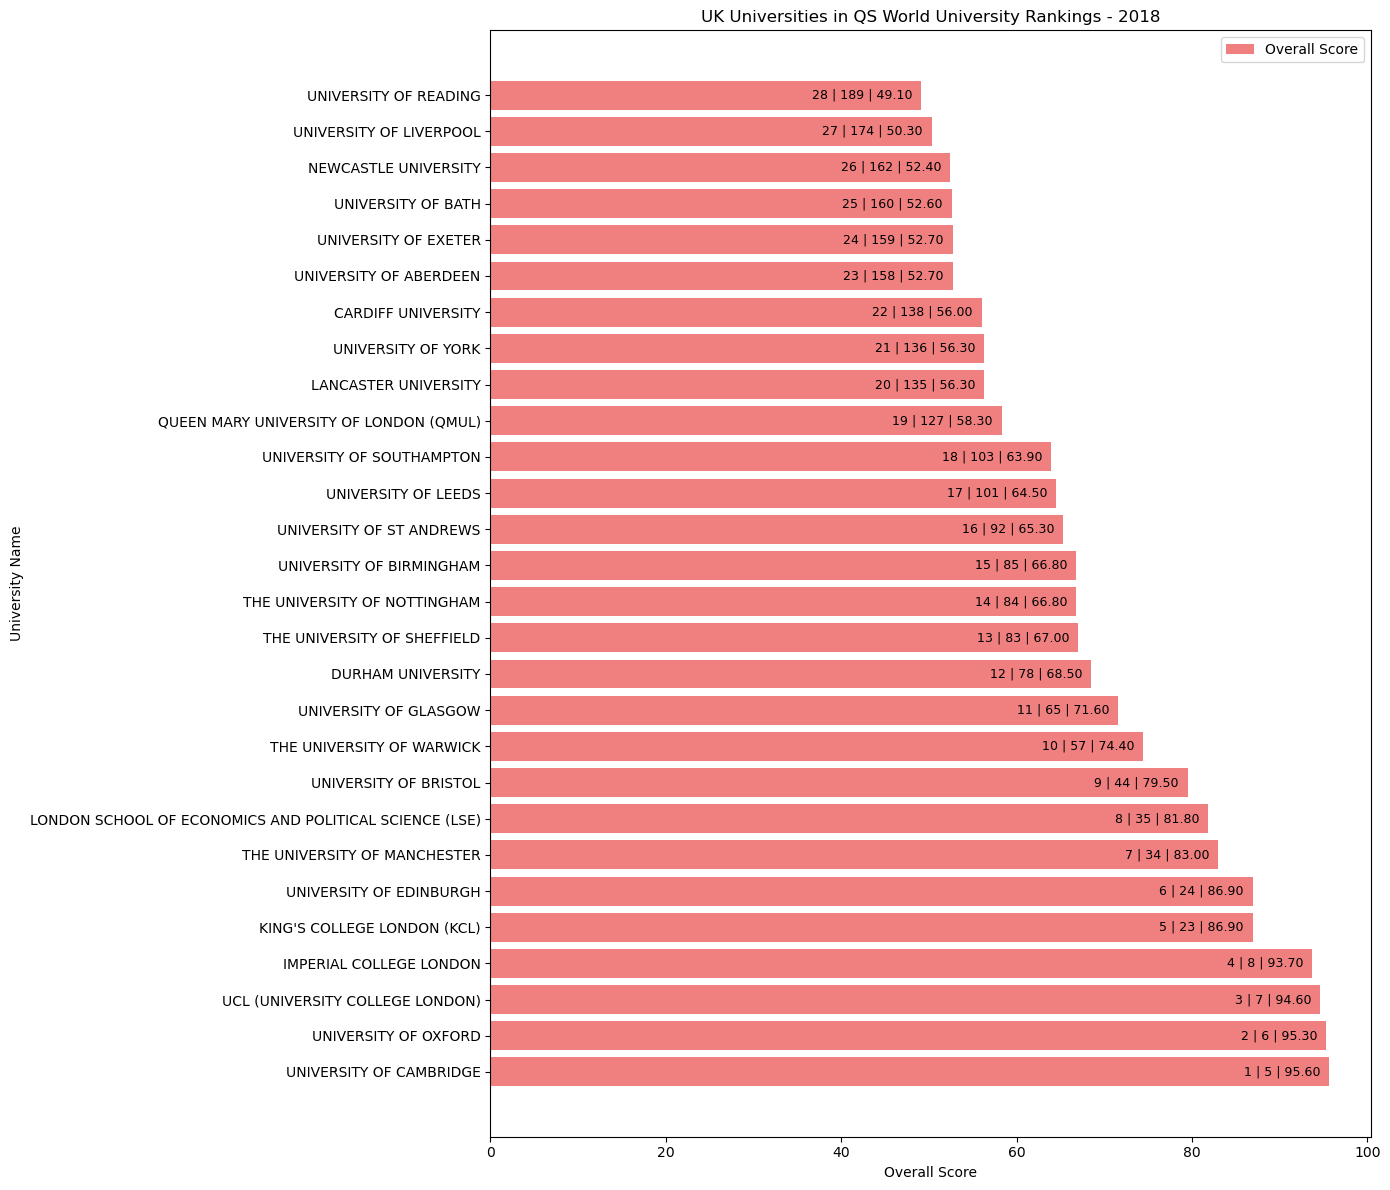

In [3]:
# CELL1

df = pd.read_excel('2018-QS-World-University-Rankings-Top200.xlsx')

uk_universities = df[df['Location'] == 'United Kingdom'].copy()
uk_universities['National Rank'] = range(1, len(uk_universities) + 1)

# Plotting bar graph
plt.figure(figsize=(14, 12))
bars = plt.barh(uk_universities['Institution Name'], uk_universities['Overall Score'], color='lightcoral')
plt.xlabel('Overall Score')
plt.ylabel('University Name')
plt.title('UK Universities in QS World University Rankings - 2018')


for i, (rank, int_rank, score) in enumerate(zip(uk_universities['National Rank'], uk_universities['Rank'], uk_universities['Overall Score'])):
    plt.text(score - 1, i, f"{rank} | {int_rank} | {score:.2f}", va='center', ha='right', color='black', fontsize=9)

plt.legend(['Overall Score'], loc='upper right')
plt.tight_layout()
plt.show()



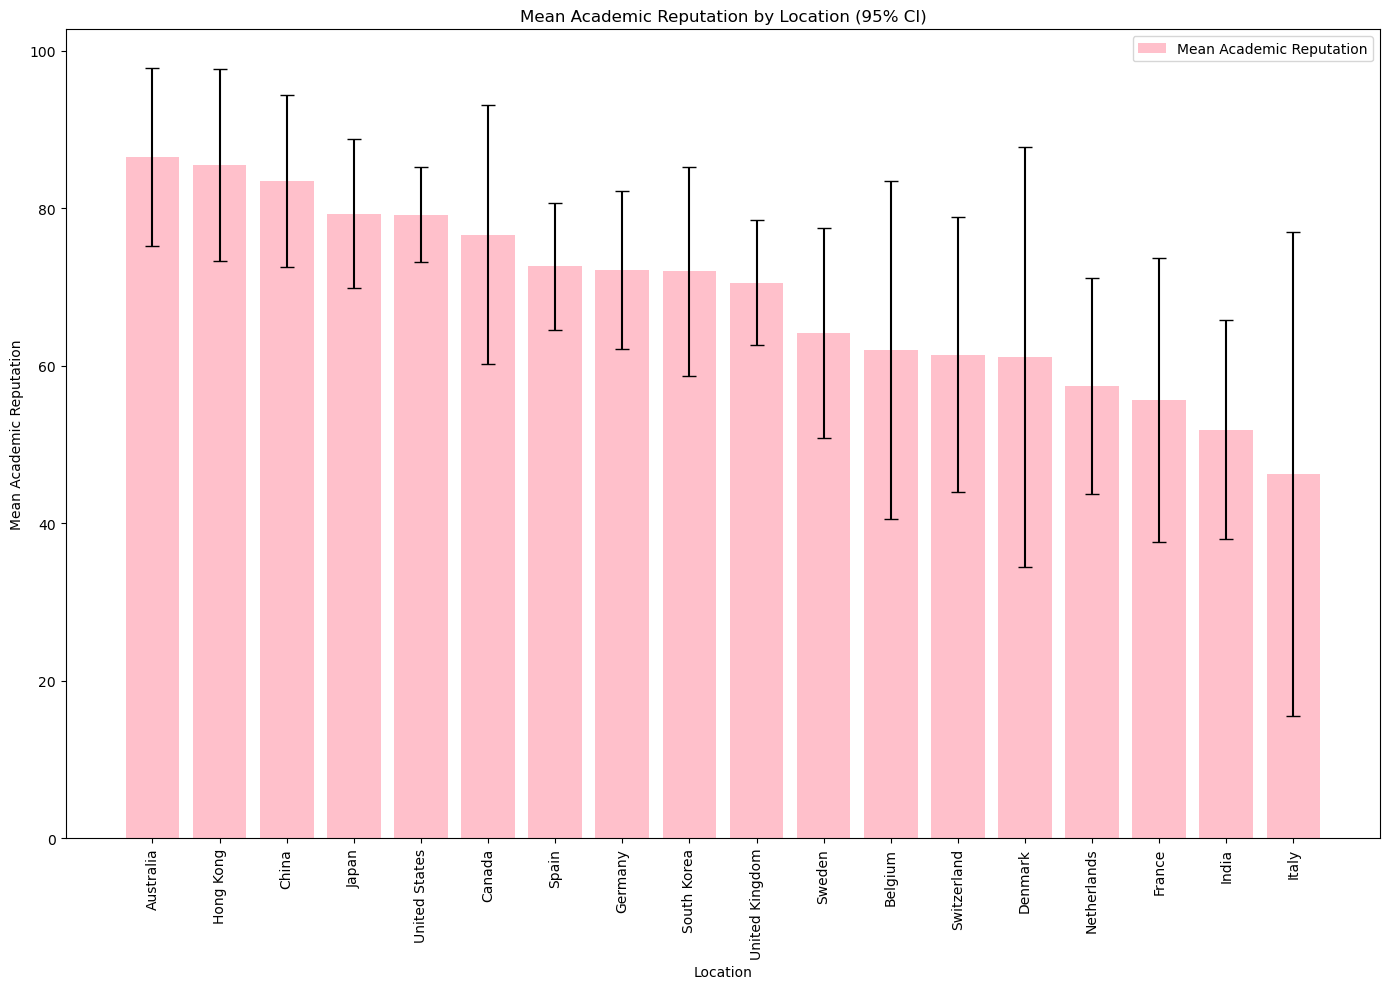

In [4]:
# CELL2

df = pd.read_excel('2018-QS-World-University-Rankings-Top200.xlsx')
location_groups = df.groupby('Location').filter(lambda x: len(x) >= 3)

mean_reputation = location_groups.groupby('Location')['Academic Reputation'].mean()
conf_interval = location_groups.groupby('Location')['Academic Reputation'].agg(lambda x: stats.sem(x) * 1.96)


reputation_data = pd.DataFrame({
    'Mean Academic Reputation': mean_reputation,
    'Confidence Interval': conf_interval
}).sort_values(by='Mean Academic Reputation', ascending=False)


plt.figure(figsize=(14, 10))
bars = plt.bar(reputation_data.index, reputation_data['Mean Academic Reputation'], 
               yerr=reputation_data['Confidence Interval'], capsize=5, color='pink')

plt.xlabel('Location')
plt.ylabel('Mean Academic Reputation')
plt.title('Mean Academic Reputation by Location (95% CI)')
plt.xticks(rotation=90)
plt.legend(['Mean Academic Reputation'], loc='upper right')

plt.tight_layout()
plt.show()




In [5]:
# CELL3


df = pd.read_excel('2018-QS-World-University-Rankings-Top200.xlsx')
countries_to_analyse = ['Australia', 'United States', 'France']

selected_data = df[df['Location'].isin(countries_to_analyse)]
academic_reputation_australia = selected_data[selected_data['Location'] == 'Australia']['Academic Reputation']
academic_reputation_us = selected_data[selected_data['Location'] == 'United States']['Academic Reputation']
academic_reputation_france = selected_data[selected_data['Location'] == 'France']['Academic Reputation']

# Australia vs United States
t_stats_aus_vs_us, p_value_aus_vs_us = stats.ttest_ind(academic_reputation_australia, academic_reputation_us)
if p_value_aus_vs_us < 0.05:
    result_australia_vs_us = "there is a significant difference in Academic Reputation between Australia and the United States."
else:
    result_australia_vs_us = "there is no significant difference in Academic Reputation between Australia and the United States."

# Australia vs France
t_stats_aus_vs_france, p_value_aus_vs_france = stats.ttest_ind(academic_reputation_australia, academic_reputation_france)
if p_value_aus_vs_france < 0.05:
    result_australia_vs_france = "there is a significant difference in Academic Reputation between Australia and France."
else:
    result_australia_vs_france = "there is no significant difference in Academic Reputation between Australia and France."

# United States vs France
t_stats_us_vs_france, p_value_us_vs_france = stats.ttest_ind(academic_reputation_us, academic_reputation_france)
if p_value_us_vs_france < 0.05:
    result_us_vs_france = "there is a significant difference in Academic Reputation between the United States and France."
else:
    result_us_vs_france = "there is no significant difference in Academic Reputation between the United States and France."

# Print the results with explanations
print("Australia vs United States:")
print(f"Test: Independent T-test\nExplanation: The Independent T-test was chosen to compare the Academic Reputation means between Australia and the United States. "
      f"The p-value of {p_value_aus_vs_us:.3f} indicates that {result_australia_vs_us}\n")

print("Australia vs France:")
print(f"Test: Independent T-test\nExplanation: The Independent T-test was chosen to compare the Academic Reputation means between Australia and France. "
      f"The p-value of {p_value_aus_vs_france:.3f} indicates that {result_australia_vs_france}\n")

print("United States vs France:")
print(f"Test: Independent T-test\nExplanation: The Independent T-test was chosen to compare the Academic Reputation means between the United States and France. "
      f"The p-value of {p_value_us_vs_france:.3f} indicates that {result_us_vs_france}\n")



Australia vs United States:
Test: Independent T-test
Explanation: The Independent T-test was chosen to compare the Academic Reputation means between Australia and the United States. The p-value of 0.337 indicates that there is no significant difference in Academic Reputation between Australia and the United States.

Australia vs France:
Test: Independent T-test
Explanation: The Independent T-test was chosen to compare the Academic Reputation means between Australia and France. The p-value of 0.011 indicates that there is a significant difference in Academic Reputation between Australia and France.

United States vs France:
Test: Independent T-test
Explanation: The Independent T-test was chosen to compare the Academic Reputation means between the United States and France. The p-value of 0.022 indicates that there is a significant difference in Academic Reputation between the United States and France.



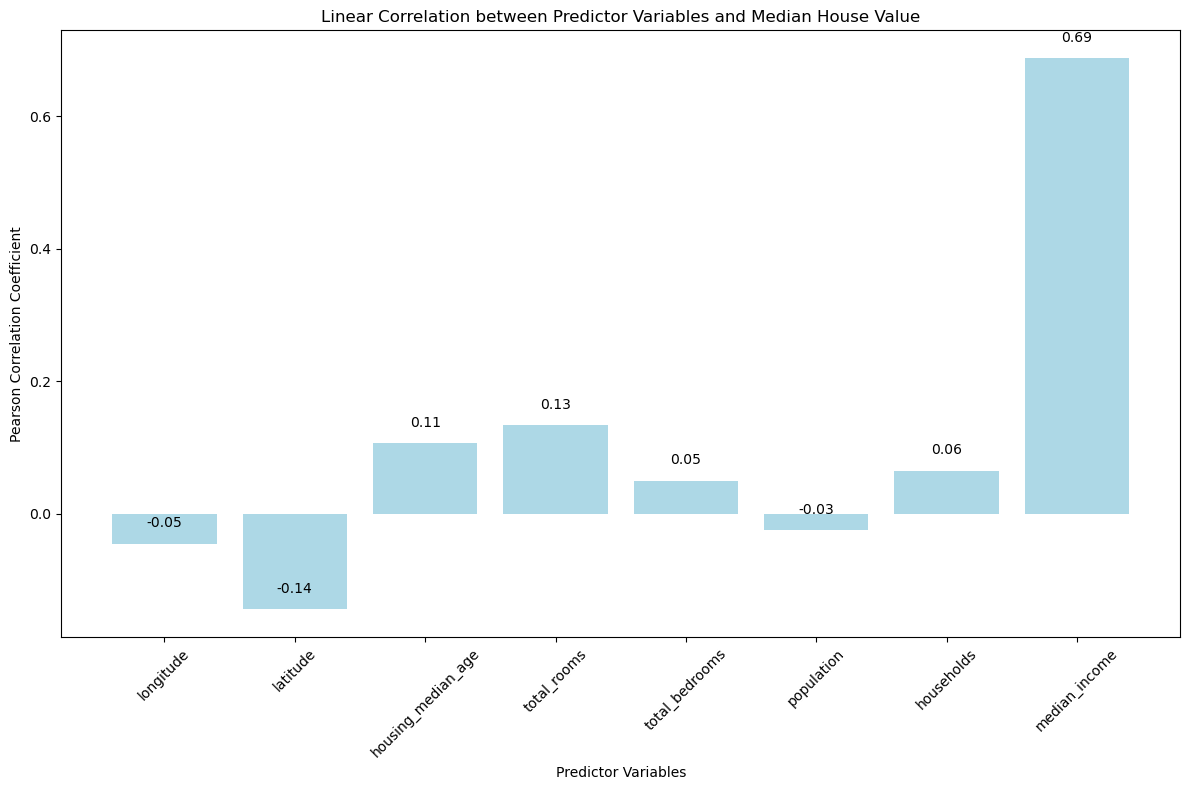

The predictor variable with the strongest correlation to the Median House Value is median_income with a coefficient of 0.69.
The predictor variable with the weakest correlation to the Median House Value is latitude with a coefficient of -0.14.


In [6]:
# CELL4

chp_df = pd.read_csv('California Housing Prices (CHP) dataset.csv').dropna()
predictor_vars = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
target_var = 'median_house_value'


correlations = chp_df[predictor_vars].corrwith(chp_df[target_var])

# plotting bar chart
plt.figure(figsize=(12, 8))
bars = plt.bar(correlations.index, correlations, color='lightblue')  


for i, corr in enumerate(correlations):
    plt.text(i, corr + 0.02, f'{corr:.2f}', ha='center', va='bottom', fontsize=10, color='black')  


plt.xlabel('Predictor Variables')
plt.ylabel('Pearson Correlation Coefficient')
plt.title('Linear Correlation between Predictor Variables and Median House Value')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


strongest_corr = correlations.idxmax()
weakest_corr = correlations.idxmin()
print(f"The predictor variable with the strongest correlation to the Median House Value is {strongest_corr} with a coefficient of {correlations[strongest_corr]:.2f}.")
print(f"The predictor variable with the weakest correlation to the Median House Value is {weakest_corr} with a coefficient of {correlations[weakest_corr]:.2f}.")



Model A: MHV = 149924.19 + 42101.61*MI + 1969.37*HA + 3.72*TR + -4833.61*LA
Model B: MHV = -3763809.28 + 37321.80*MI + 1159.75*HA + 3.32*TR + -43925.26*LA + -44738.59*LO


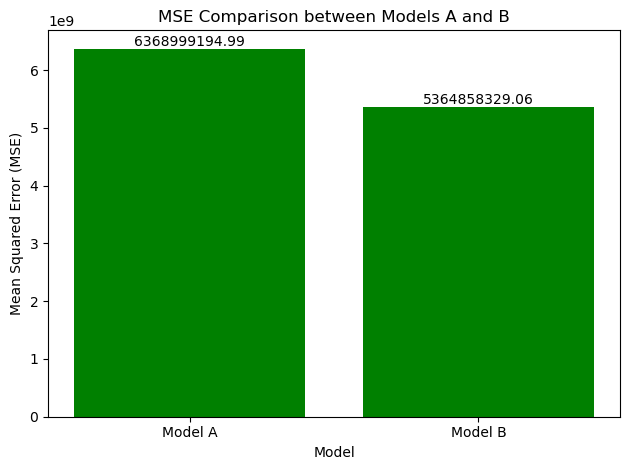

The model with the best performance based on MSE is Model B.


In [7]:
# CELL5

X_A = chp_df[['median_income', 'housing_median_age', 'total_rooms', 'latitude']]
y = chp_df['median_house_value']

X_A = sm.add_constant(X_A)

model_A = sm.OLS(y, X_A).fit()

X_B = chp_df[['median_income', 'housing_median_age', 'total_rooms', 'latitude', 'longitude']]
X_B = sm.add_constant(X_B)

model_B = sm.OLS(y, X_B).fit()

mse_A = np.mean((model_A.predict(X_A) - y) ** 2)
mse_B = np.mean((model_B.predict(X_B) - y) ** 2)

print(f"Model A: MHV = {model_A.params.iloc[0]:.2f} + {model_A.params.iloc[1]:.2f}*MI + {model_A.params.iloc[2]:.2f}*HA + {model_A.params.iloc[3]:.2f}*TR + {model_A.params.iloc[4]:.2f}*LA")
print(f"Model B: MHV = {model_B.params.iloc[0]:.2f} + {model_B.params.iloc[1]:.2f}*MI + {model_B.params.iloc[2]:.2f}*HA + {model_B.params.iloc[3]:.2f}*TR + {model_B.params.iloc[4]:.2f}*LA + {model_B.params.iloc[5]:.2f}*LO")

# Compare performance of both models based on MSE
mse_values = [mse_A, mse_B]
models = ['Model A', 'Model B']

plt.bar(models, mse_values, color='green')
plt.xlabel('Model')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('MSE Comparison between Models A and B')

# Add MSE values on top of bar
for i, mse in enumerate(mse_values):
    plt.text(i, mse + 0.05, f'{mse:.2f}', ha='center', va='bottom', fontsize=10)  # Adjust the position and fontsize if needed

plt.tight_layout()
plt.show()

best_model = models[np.argmin(mse_values)]
print(f"The model with the best performance based on MSE is {best_model}.")



In [8]:
# CELL6

print("We compared the two models by looking at their Mean Squared Error (MSE). Model B, which includes Longitude, has a slightly lower MSE, making it a bit more accurate than Model A. However, the difference is small, meaning Longitude doesn’t have a huge impact on the predictions. Some limitations of this comparison include the possibility of predictor variables being too similar to each other and the assumption that the relationships between variables are always linear. Also, other factors not included in the dataset might affect the model’s accuracy in real-world situations.")



We compared the two models by looking at their Mean Squared Error (MSE). Model B, which includes Longitude, has a slightly lower MSE, making it a bit more accurate than Model A. However, the difference is small, meaning Longitude doesn’t have a huge impact on the predictions. Some limitations of this comparison include the possibility of predictor variables being too similar to each other and the assumption that the relationships between variables are always linear. Also, other factors not included in the dataset might affect the model’s accuracy in real-world situations.


In [9]:
import scipy
print(scipy.__version__)

1.13.1
